### Churn Prediction Project

We aim to train a classification model to predict churn rate of a telecommunaication company data. 

From this project, we will be able to identify the following:

- At risk customers, customers likely to churn.
- Customer pain point, posssible drivers for churn.

**About Dataset**

This data set is dataset made available for my apprenticeship project, but can be easily gotten from kaggle. This sample data tracks tracks a fictional telecommunications comapny, Telco. It includes a target label, churn, indicating if a customer has left the company, and other dependent features that cover customer demographics, services subscribed to, and account information. 
The dataset has 7043 rows and 20 features.

#### Exploratory Data Analysis (EDA)

We are going to do some exploratory analysis to understand the different features, and the relationship between them and churn. 
We are going to analyze the data with visualizations, with the matplotlib and seaborn libraries, to summmarize the main  characteristics of the dta. 

Lets explore the data to discover pattern and visualize how features relate with churn

#### Data Preparation

We be begin by importing the necessary libraries and loading in our dataset

In [4]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
# load and display the data
data = pd.read_csv('Telecoms Company data.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
data.shape

(7043, 21)

In [6]:
# summary info of the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# checking for null values 
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

There ar no null values

In [9]:
# checking for duplicates 
data.duplicated().sum()

0

There are no duplicate values

In [10]:
# statistical summary
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [32]:
# checking unique values for each column
for column in data:
    print(f'{column}: {data[column].nunique()}')

customerID: 7043
gender: 2
SeniorCitizen: 2
Partner: 2
Dependents: 2
tenure: 73
PhoneService: 2
MultipleLines: 3
InternetService: 3
OnlineSecurity: 3
OnlineBackup: 3
DeviceProtection: 3
TechSupport: 3
StreamingTV: 3
StreamingMovies: 3
Contract: 3
PaperlessBilling: 2
PaymentMethod: 4
MonthlyCharges: 1585
TotalCharges: 6531
Churn: 2


Total charges column which should be a numeric column is not. We will correct that.
SeniorCitizen column has 2 unique values; 0 and 1, therefore the statistical summary of the Senior Citizen column doesn't tell us much.

In [36]:
# changing totalcharges column to a numeric column
data['TotalCharges'] = data['TotalCharges'].astype(float)

In [34]:
data['TotalCharges'].value_counts()

          11
20.2      11
19.75      9
20.05      8
19.9       8
          ..
6849.4     1
692.35     1
130.15     1
3211.9     1
6844.5     1
Name: TotalCharges, Length: 6531, dtype: int64

It seems like there are 11 empty strings in the TotalCharges column.

In [37]:
# dropping rows with empty string in total charge column and tehn we change the data type
data = data[~(data['TotalCharges'] == ' ')]

In [42]:
data.shape

(7032, 21)

In [47]:
# checking for outliers

In [45]:
# checking for outliers in total charges column
# defining quantiles
q1 = data['TotalCharges'].quantile(0.25)
q3 = data['TotalCharges'].quantile(0.75) 
iqr = q3 - q1

# defining thresholds
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# subsetting for outlier
df_out = data[(data['TotalCharges'] < lower) & (data['TotalCharges'] > upper)]
# There are 0 outliers in the total charges column

In [ ]:
Next we create bins for the tenure column 

<AxesSubplot:>

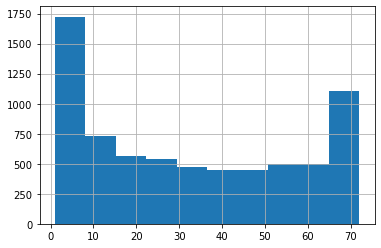

In [50]:
data['tenure'].hist()

Lets create 3 bins for the tenure column for easy visualization and understanding

In [ ]:
# create tenure group
data['tenureGroup'] = data

In [69]:
# defining a function to group tenure
def group_tenure(tenure):
    if tenure < 25:
        return "Low"
    elif tenure < 49: 
        return "Medium"
    else :
        return "High"

# Apply the function to the 'tenure' column
data['tenureGroup'] = data['tenure'].apply(group_tenure)

Ater data validation, we have 7032 rows and 22 columns.

From the 22 columns, there are 18 categorical features, 3 numerical columns and one target feature, Churn


**lets explore the target variable**

In [220]:
# Define a color palette for churn
colors = {
    "No": "teal",
    "Yes": "brown"
}

Churn
No     5163
Yes    1869
Name: Churn, dtype: int64


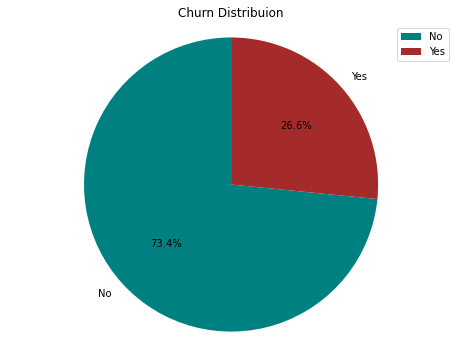

In [116]:
# let's see the customers who have churned
print("Churn")
print(data['Churn'].value_counts())

# pie chart showing customer count by churn
# Count the occurrences of each category from the fuelType column
category_counts = data['Churn'].value_counts()


# Create a pie chart
plt.figure(figsize=(8, 6))
plt.pie(category_counts, labels=category_counts.index,autopct='%1.1f%%', startangle=90, colors=['teal','brown'])
plt.axis('equal')  
plt.title('Churn Distribuion')
# Add a legend
plt.legend(category_counts.index, loc='upper right')  # Adjust location as needed
plt.show()
plt.show()

This shows that 73.4% of customer have not churned and 26.6% have churned. 

**Lets understand categorical features**

There are different features that tell us different information about the customer. 
- customer infomation: gender, senoircitizen, patner, dependents, tenuregroup.
- customer services: phoneservice, online backup, device protection, tech support, streaming movie, streaming tv.
- customer account: payment method, monthly charges, total charegs, contract, paperless billing.

Lets explore these

In [224]:
# function to plot categorical features
def countplot_with_annotation(data, feature, target, colors, ax):
    # Create the countplot
    sns.countplot(x=feature, hue=target, data=data, palette=colors, ax=ax)

    # Calculate totals for annotations
    total = len(data[feature])
    counts = data[feature].value_counts()

    # Loop through the patches (bars) of the countplot
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_x(), p.get_y()
        # Calculate percentage and format as string
        percentage = f'{100 * height/total:.1f}%'
        # Place the text at (x + width/2, y + height) coordinates
        ax.text(x + width/2, y + height, percentage, ha='center', va='bottom')

    # Optional: Add an overall comment about the distribution
    comment = f"Total entries: {total}\nDistribution details:\n" + "\n".join([f"{idx}: {val} ({100 * val / total:.1f}%)" for idx, val in counts.items()])
    # Position this text outside the plot
    ax.text(1.05, 0.5, comment, transform=ax.transAxes, ha='left', va='center')

def plot_categorical_features(data, features, target, colors):
    # Set up the matplotlib figure
    fig, axes = plt.subplots(nrows=len(features), ncols=1, figsize=(12, 6 * len(features)))
    if len(features) == 1:
        axes = [axes]  # Ensure axes is iterable for a single subplot

    # Create each plot
    for ax, feature in zip(axes, features):
        countplot_with_annotation(data, feature, target, colors, ax)

    plt.tight_layout()
    plt.show()



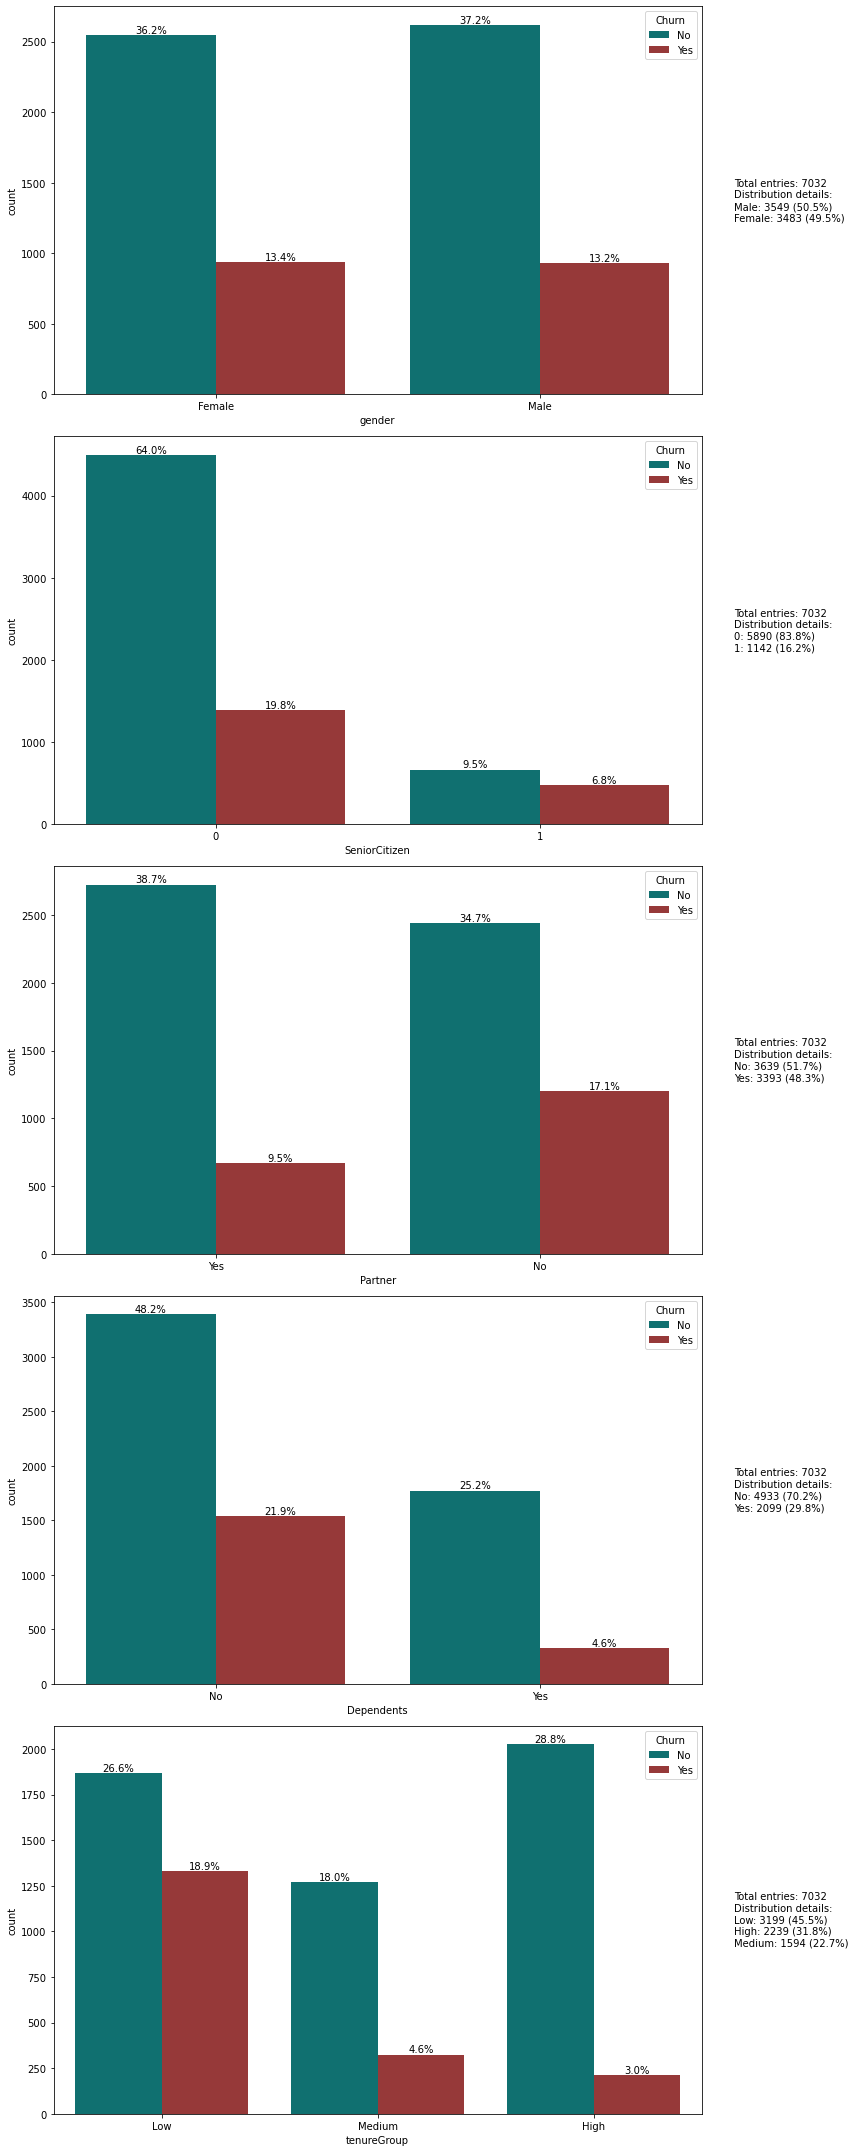

In [225]:
# plotting charts for customer information with distribution information
feature_information = ['gender','SeniorCitizen','Partner','Dependents','tenureGroup']

plot_categorical_features(data=data, features=feature_information, target='Churn', colors=colors)

From the visualization, we observed the following:
- The distributon of gender between customers and their churn rate is similar.
- Churn rate for senoir citizen is lower than for not senoir citizen. Younger customers tend to churn more. Most of the customers, more tha 80%, are not citizen. which also explains why they have a higher churn rate. 
- Churn rate for single people are higher than for people with patners, even htough they are evenly distributed
- Customers with dependents are less likely to churn than customers without dependents.
- Customers that have been with the company for one year or less have the highest rate of churn. this imploes, the longer the customer has been a customer, the less likely for the customer to churn.

Next we explore the different services of the customers

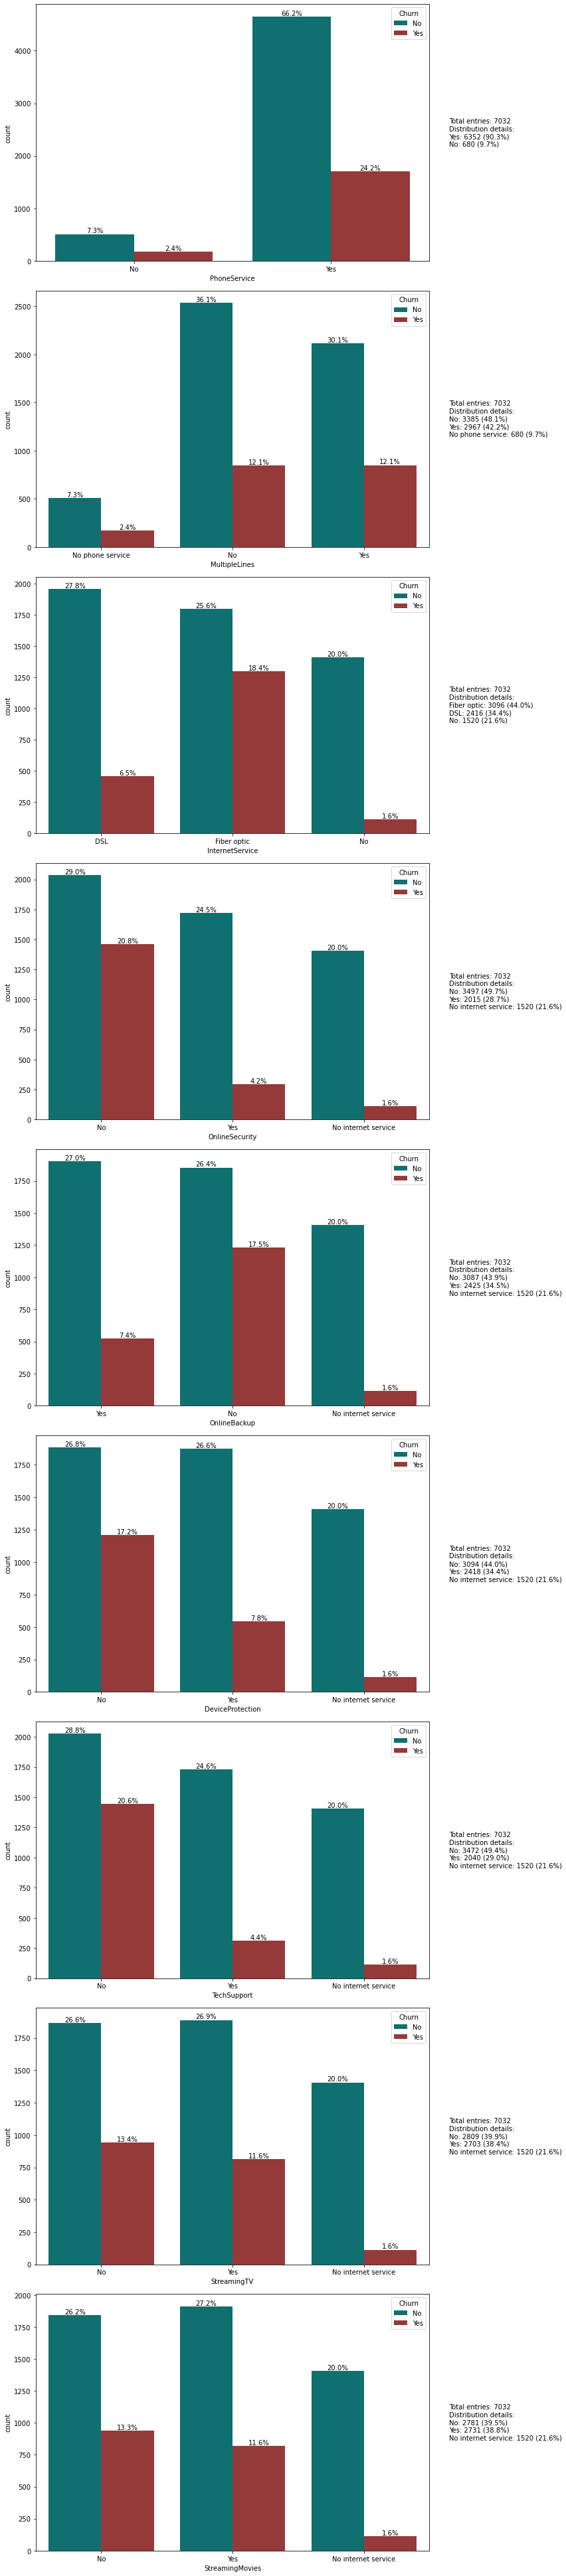

In [226]:
# plotting charts for customer service with distribution information
feature_services = ['PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies',]

plot_categorical_features(data=data, features=feature_services, target='Churn', colors=colors)

The information of the various services the customers signed upfor gives us some interesting information about the distribution and the churn rate:
- Over 90% of customers have phone service, so a huge percentage of these tend to curn.
- For customers with multiple lines, the churn rate is similar between those who have and those who don't.
- For customers with internet service, customers with fiber optic service have the highest rate of churn, while those with no internet service have a very low churn rate.
- Almost half of the customers didn't sign up for Online security, and those from this group have a very high chance of churn, more than 70% churn. As for customers who signed up for internet security, the churn rate is 17%, while those with no internetservice have a lower rate of churn, 8%.
- For online backup, Those who didn't sign up have a very rate of churn too. also, 27% of those who signed up for the service churned., which is also simlar to device protection service, 29% churnrate for device protection, out of those who sihned up for the service. with 17% also for device tech support.
- Streaming tv and streaming movies services have similar churn rate for those who subscribed to the service and those who did not. 
- those who didnt sign up for servoces like online security, online backup, device protetion, tech support, streaming movies , streaming tv and multiple lines are more likely to churn than those who did.    

Lets look at the account information of the customers to understand payment method of the customers

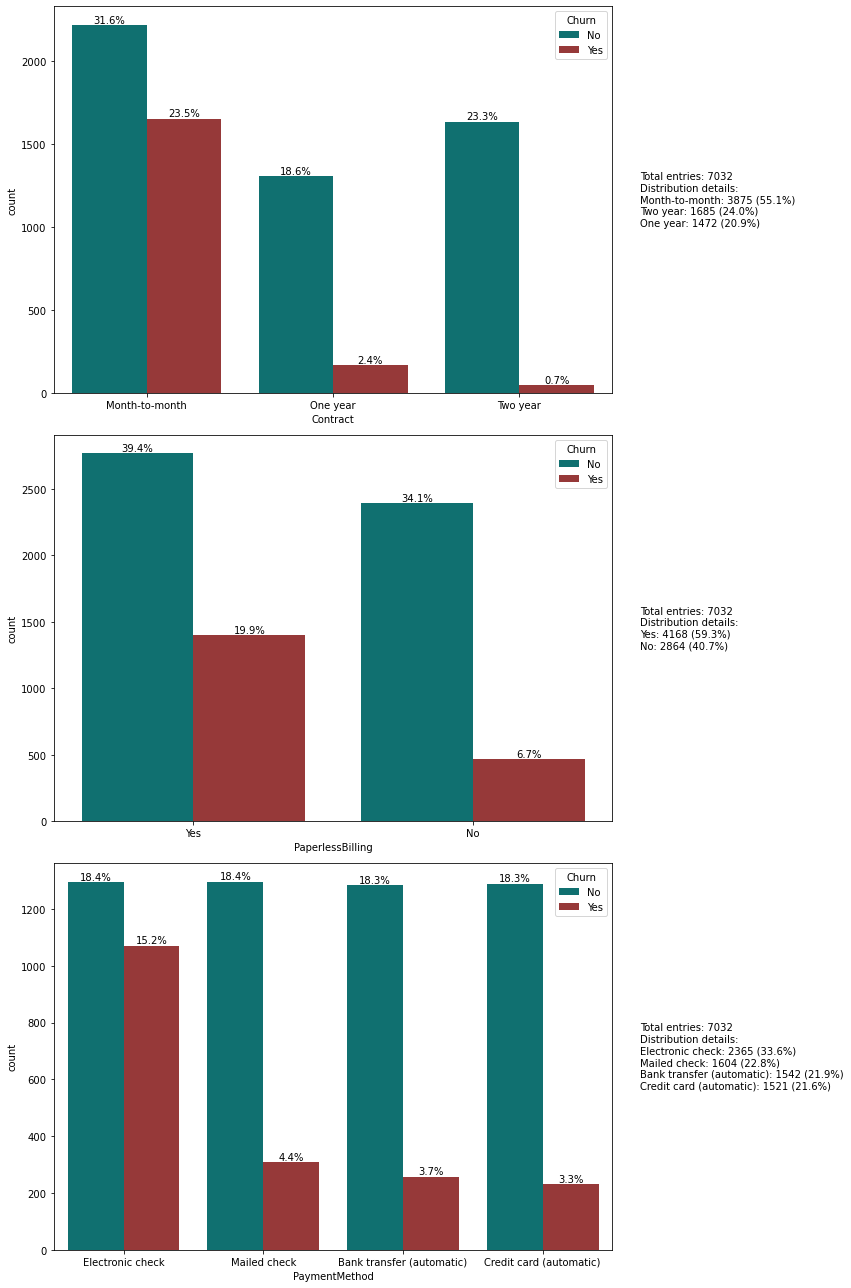

In [227]:
# plotting charts for customer service with distribution information
feature_account = ['Contract','PaperlessBilling','PaymentMethod']

plot_categorical_features(data=data, features=feature_account, target='Churn', colors=colors)

The different payment methods of the customers gives us some interesting insights:
   - Customers with month to month contract have the highest churn rate, and they also account for more than 50% of the total customers. and more than 70% of those churn. 
   - Customers with paperless billing ,60% of total cutomers, are also more likely to churn wuth a 50% churn rate. 
   - customers using electronic check for their payment method, over 30% of total customers, are the most likely to churn with a 82.6% churn rate. this is very concerning as it is a ttola of 15.@ perecnt churn of the total churn of the customers. 

Lets look at the distribution of the numeric features of the dataset: MonthlyCharges, TotalCharges, tenure

In [194]:
def histogram(data, feature_list, target, colors):
    for feature in feature_list:
        plt.figure(figsize=(10, 5))
        # Plotting the histogram with a KDE overlay for smoother distribution visualization
        sns.histplot(data=data, x=feature, hue=target, palette=colors, element="bars", kde=True, alpha=0.6, bins=30)
        plt.title(f'Distribution of {feature} by {target}')
        plt.xlabel(feature)
        plt.ylabel('Frequency')
        # Ensure the legend is displayed
        #plt.legend(title=target, labels=list(data[target].unique()))
        #plt.legend(title=target, labels=["No", "Yes"])
        plt.show()


In [ ]:
# function to lot histogram for numeric columns
def histogram(data, feature_list, target, colors):
    for feature in feature_list:
        plt.figure(figsize=(10,5))
        sns.histplot(x=feature, hue=target, data=data, palette=colors, alpha=0.5)
        plt.title(f'Distribution of {feature} by Churn')
        plt.xlabel(feature)
        plt.legend(title=target)
        plt.show()

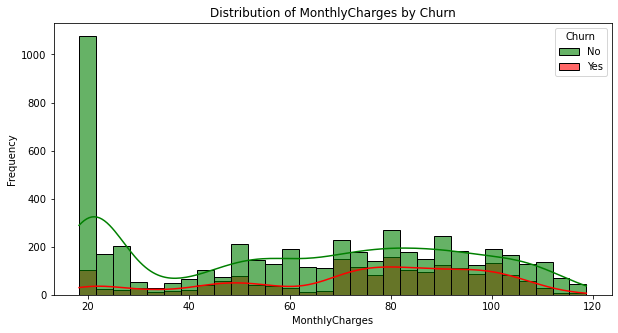

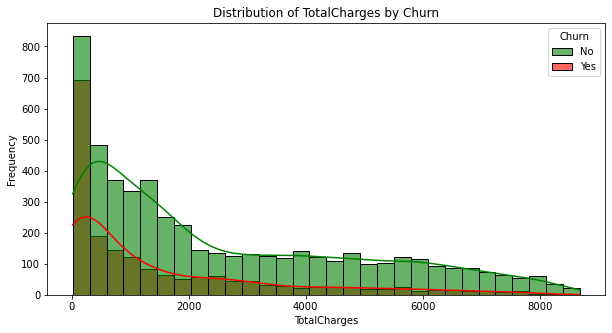

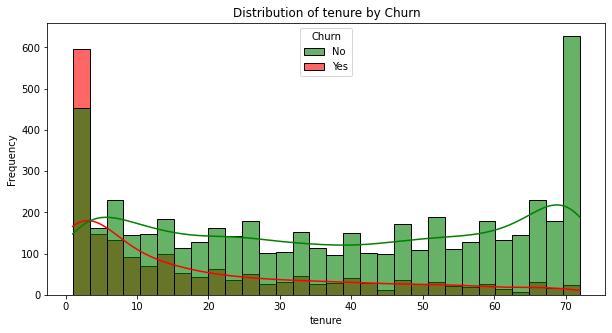

In [201]:
colors = {"Yes": "red", "No": "green"}  # Adjust according to your target categories
feature_numeric = ['MonthlyCharges', 'TotalCharges', 'tenure']  # Example numeric features
histogram(data=data, feature_list=feature_numeric, target='Churn', colors=colors)


In [ ]:
# plot histogram of numeric features
feature_numeric = ['MonthlyCharges','TotalCharges','tenure']
histogram(data=data, feature_list=feature_numeric, target='Churn',colors=colors )

# i had to use the code block aove to show th colors.

In [202]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


The histogram shows that the frquency for churn rate for people paying between 0 - 2000 has the highest chance of churning. This could also be because they ara a large proportion of the total charges. From the summary statistics, 25% percent of people pay above almost 4000 with the highest at 8000. Also, customers paying etween 70 and 105 for mostly charges has higher chances of churning than customers who do not. Tenure distriution tells what what the tenure group has already showm; lower the tenure highre chnaces of churn and vice versa.

In [160]:
# checking correlation of the numeric columns
data[['tenure','MonthlyCharges','TotalCharges']].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.246862,0.825880
MonthlyCharges,0.246862,1.000000,0.651065
TotalCharges,0.825880,0.651065,1.000000


There is some really positive relationship between some columns; tenure and monthly charges, and total charges and monthly charges.

Lets visualize this in scatterplot to view their relationsip

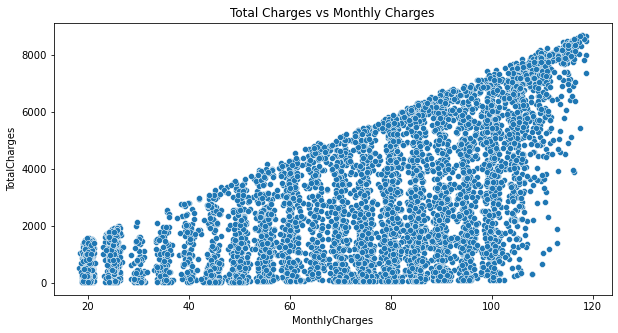

In [203]:
# scatter plot
plt.figure(figsize=(10,5))
sns.scatterplot(x='MonthlyCharges',y='TotalCharges', data=data)
plt.title("Total Charges vs Monthly Charges")
plt.show()

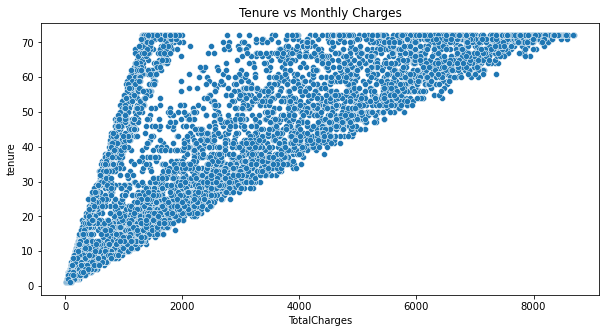

In [205]:
# scatter plot
plt.figure(figsize=(10,5))
sns.scatterplot(x='TotalCharges',y='tenure', data=data)
plt.title("Tenure vs Monthly Charges")
plt.show()

From the scatterplot we saw a positive linear relation between monthly charges and total charges which makes complete sense, as the customer monthly charge increase, the total charge increaeses, which also explains the second plot, as the tenure increases, monthly charges increases, which also increase total charge. 

In [ ]:
# data ready for model preprocessing and training
data.to_csv('data_clean.csv',index=False)

### Data Preprocessing

Now we have a better understanding of the datset, we will go ahead to prepare our data before training our dataset in the selected models. This process will include selecting features for model training, encoding categorical features for machine learning, scaling of the numerical features and splitting of the dataset into train and test set to evaluate the performance of the models. 

In [5]:
# load data
df = pd.read_csv('data_clean.csv')

In [6]:
# dropping columns that is not needed: 
df = df.drop(columns=['customerID','tenureGroup'],axis=1)

In [7]:
df.shape

(7032, 20)

**pipeline for preprocessing**

In [1]:
# import libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import FunctionTransformer

In [8]:
binary_columns = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
categorical_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
gender_col = ['gender']

# Encoding the target variable 
df['Churn'] = df['Churn'].replace({'Yes':1, 'No':0})

def binary_encode(df):
    binary_columns = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
    df.loc[:, binary_columns] = df[binary_columns].replace({'Yes': 1, 'No': 0})
    return df

# function to encode gender column
def gender_encode(df):
    df['gender'] = df['gender'].replace({'Male':1, 'Female':0})
    return df

# manually encode churn column
df['Churn'] = df['Churn'].replace({'Yes':1, 'No':0})

# Create a transformer for binary encoding
binary_transformer = FunctionTransformer(binary_encode)

# create a transformer for gender encoding
gender_transformer = FunctionTransformer(gender_encode)

# Encode other categorical columns using one-hot encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# scaling numeric features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

# combine into a single column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('binary', binary_transformer, binary_columns),
        ('gender', gender_transformer, gender_col),
        ('cat', categorical_transformer, categorical_cols),
        ('num', numeric_transformer, numerical_cols)
    ],
    remainder='passthrough'  # This passes through other features not specified without transformation
)

**split data**

In [10]:
from sklearn.model_selection import train_test_split

# Define features and target
x = df.drop('Churn', axis=1)
y = df['Churn']

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)


In [11]:
# Check if all expected columns are in the DataFrame
expected_columns = set(binary_columns + gender_col + categorical_cols + numerical_cols)
actual_columns = set(x_train.columns)
missing_columns = expected_columns - actual_columns

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All columns are present. Proceeding with preprocessing.")


All columns are present. Proceeding with preprocessing.


In [12]:
# Fit the preprocessor on the training data and transform it
x_train1 = preprocessor.fit_transform(x_train)
# transform test data
x_test1 = preprocessor.transform(x_test)

**model training**

In [13]:
# import libraries for model training evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve


**the models:**

In [14]:
# Define the models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "GradientBoost": GradientBoostingClassifier(random_state=42)
}


**training models and evaluating result**

In [15]:
# Initialize a list to store results
models_cv = []

# Train and evaluate models
for name, model in models.items():
    model.fit(x_train1, y_train)
   
    cv_accuracy = cross_val_score(model, x_train1, y_train, cv=5, scoring="accuracy")
    cv_auc = cross_val_score(model, x_train1, y_train,cv = 5, scoring="roc_auc")
    cv_recall = cross_val_score(model, x_train1, y_train, cv=5, scoring="recall")
    cv_f1 = cross_val_score(model, x_train1, y_train, cv=5, scoring="f1")
    models_cv.append({
        "Model": name,
        "Accuracy": cv_accuracy.mean(),
        "ROC": cv_auc.mean(),
        "Recall" : cv_recall.mean(),
        "F1": cv_f1.mean(),
        "CV Score Std": cv_accuracy.std()
    })

    
# create df from the result list
multiple_cv = pd.DataFrame(models_cv)

# Sort the DataFrame by the F1 Score for better visualization
multiple_cv.sort_values(by="F1", ascending=False, inplace=True)

# Display the results DataFrame
multiple_cv

,Model,Accuracy,ROC,Recall,F1,CV Score Std
0,Logistic Regression,0.802667,0.845937,0.548495,0.596498,0.012304
5,AdaBoost,0.804622,0.845849,0.543144,0.596369,0.011458
6,GradientBoost,0.801600,0.845736,0.521070,0.582813,0.014793
3,SVM,0.800889,0.797373,0.494314,0.569202,0.011992
2,Random Forest,0.786311,0.822010,0.487625,0.548202,0.011986
4,KNN,0.767822,0.777938,0.527759,0.547129,0.009244
1,Decision Tree,0.730667,0.663014,0.518395,0.505739,0.008301


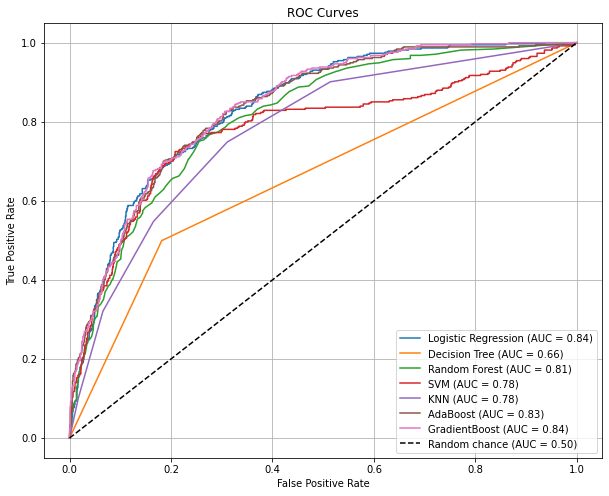

In [16]:
# Roc curve and roc-auc score
plt.figure(figsize=(10, 8))

# Train and plot ROC curve for each model
for name, model in models.items():
    model.fit(x_train1, y_train)
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(x_test1)[:, 1]
    else:
        # For models that do not support predict_proba (usually shouldn't reach here for models listed)
        proba = model.decision_function(x_test1)
        proba = (proba - proba.min()) / (proba.max() - proba.min())  # Scale to [0,1]
    
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random chance (AUC = 0.50)")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [17]:
# Getting classification report and matrix of all the models

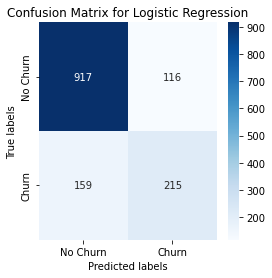

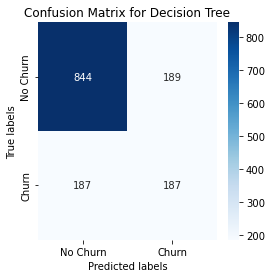

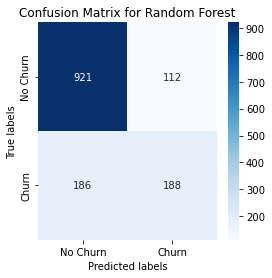

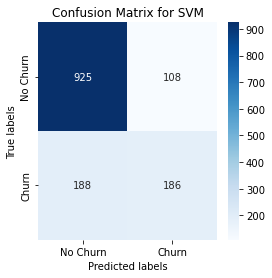

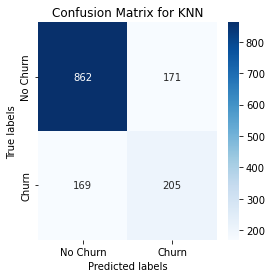

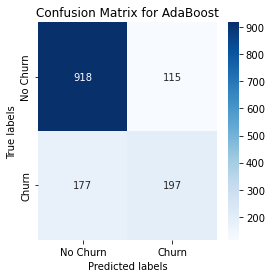

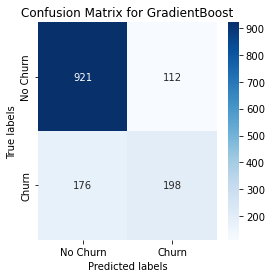

In [18]:
for name, model in models.items():
    # Predict using the current model
    predictions = model.predict(x_test1)

    # Compute the confusion matrix
    cm = confusion_matrix(y_test, predictions)

    # Plot the confusion matrix
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.title(f'Confusion Matrix for {name}')
    plt.show()


In [22]:
# classification report
for name, model in models.items():
    predictions = model.predict(x_test1)
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    print(f"Classification Report for {name}:")
    print(classification_report(y_test, predictions))
    print("-" * 60)  # just to separate the reports for better readability


Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

------------------------------------------------------------
Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1033
           1       0.50      0.50      0.50       374

    accuracy                           0.73      1407
   macro avg       0.66      0.66      0.66      1407
weighted avg       0.73      0.73      0.73      1407

------------------------------------------------------------
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.83      0.89      0

In [23]:
# evaluating metric of all models

# Initialize a list to store results
result_metrics = []

# Train and evaluate models
for name, model in models.items():
    model.fit(x_train1, y_train)
    predictions = model.predict(x_test1)
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    result_metrics.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })
    
# Create a DataFrame from the results list
metrics = pd.DataFrame(result_metrics)

# Sort the DataFrame by the recall for better visualization
metrics.sort_values(by="Recall", ascending=False, inplace=True)

# Display the results DataFrame
metrics

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.804549,0.649547,0.574866,0.609929
4,KNN,0.758351,0.545213,0.548128,0.546667
6,GradientBoost,0.795309,0.638710,0.529412,0.578947
5,AdaBoost,0.792466,0.631410,0.526738,0.574344
2,Random Forest,0.788202,0.626667,0.502674,0.557864
1,Decision Tree,0.732765,0.497340,0.500000,0.498667
3,SVM,0.789623,0.632653,0.497326,0.556886


**Model Chosen**

- Logistic Regression

In [25]:
# tuning the model

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Set up the parameter grid
param_grid = {
    'C': np.logspace(-4, 4, 20),  # Provides a range of C values from 10^-4 to 10^4
    'penalty': ['l2'],  # 'l1' and 'l2' are common choices, but choice depends on solver
    'solver': ['lbfgs', 'liblinear', 'sag', 'saga']  # Choose solvers that support the penalties you are testing
}

# Initialize the Logistic Regression classifier
log_reg = LogisticRegression(max_iter=10000)

# Set up GridSearchCV
grid_search_log = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)

# Fit GridSearchCV
grid_search_log.fit(x_train1, y_train)

# Best parameters and best score
print("Best parameters:", grid_search_log.best_params_)
print("Best score:", grid_search_log.best_score_)
# best parameters
best_param_log = grid_search_log.best_params_

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best parameters: {'C': 1.623776739188721, 'penalty': 'l2', 'solver': 'liblinear'}
Best score: 0.5965820605772789


In [28]:
# improving performance of the model

In [30]:
# train model
# Assuming best_param is defined
log_classifier = LogisticRegression(**best_param_log) # best_param_log is already defined
log_classifier.fit(x_train1, y_train)

# evaluate model
# Predict on the test set with selected features
y_pred = log_classifier.predict(x_test1)

# Calculate accuracy, recall, f1_score
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Recall:", recall)
print("F1 Score:", f1)
print("Precision:", precision)

# Detailed classification report
print(classification_report(y_test, y_pred))


Accuracy: 0.8038379530916845
Recall: 0.5748663101604278
F1 Score: 0.6090651558073654
Precision: 0.6475903614457831
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



The performance increased slightly.

The model improved slightly. Let’s save the model and start the deployment of our churn prediction application using this model.

**creating model pipeline**

In [32]:
# create the piprline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', log_classifier)
])

**saving model**

In [33]:
#Saving best model with joblib 
from joblib import dump, load

dump(model_pipeline, 'log_model.joblib')

['log_model.joblib']

In [34]:
# saving model with pickle
import pickle

# Saving the model
with open('log_model.pkl', 'wb') as file:
    pickle.dump(model_pipeline, file)

print("Model saved successfully!")

Model saved successfully!


**Conclusion**

Churn rate is an important indicator for subscription-based companies. Identifying customers who aren’t happy can help managers identify product or pricing plan weak points, operation issues, as well as customer preferences and expectations. When you know all that, it’s easier to introduce proactive ways of reducing churn.